In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("green_tripdata_2021-01.parquet")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               76518 non-null  int64         
 1   lpep_pickup_datetime   76518 non-null  datetime64[us]
 2   lpep_dropoff_datetime  76518 non-null  datetime64[us]
 3   store_and_fwd_flag     40471 non-null  str           
 4   RatecodeID             40471 non-null  float64       
 5   PULocationID           76518 non-null  int64         
 6   DOLocationID           76518 non-null  int64         
 7   passenger_count        40471 non-null  float64       
 8   trip_distance          76518 non-null  float64       
 9   fare_amount            76518 non-null  float64       
 10  extra                  76518 non-null  float64       
 11  mta_tax                76518 non-null  float64       
 12  tip_amount             76518 non-null  float64       
 13  tolls_amount

In [4]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,0.50,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,0.50,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,0.50,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,0.50,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,0.00,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,NaN,NaN,81,90,NaN,17.63,56.23,2.75,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,NaN,NaN,35,213,NaN,18.36,46.66,0.00,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,NaN,NaN,74,69,NaN,2.50,18.95,2.75,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,NaN,NaN,168,215,NaN,14.48,48.87,2.75,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN


I had AI generate some plots to get a better overview.

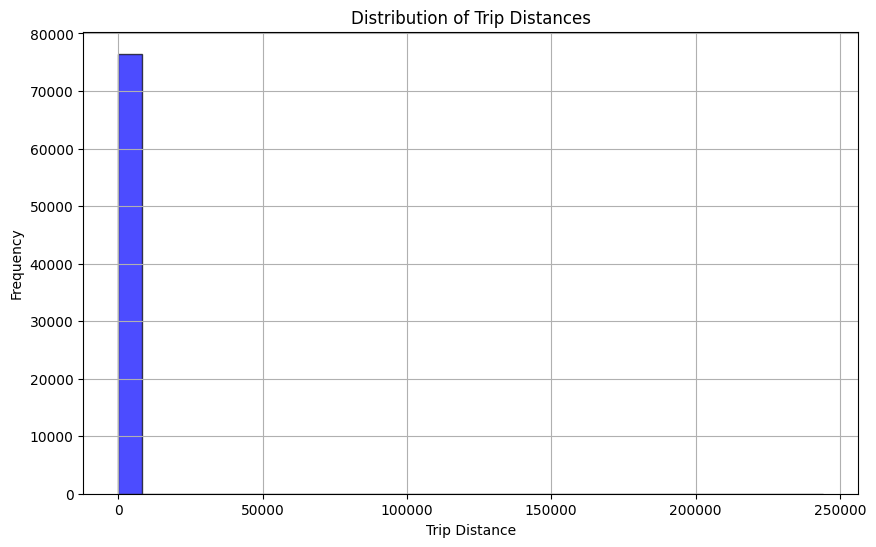

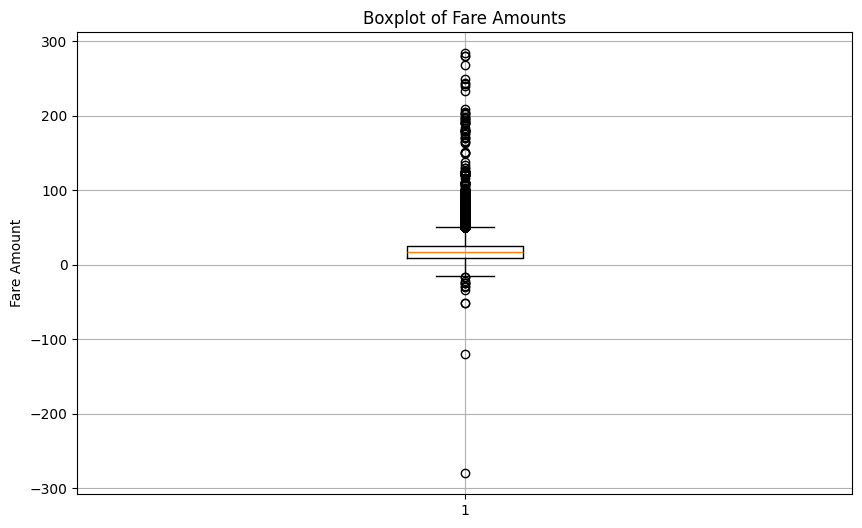

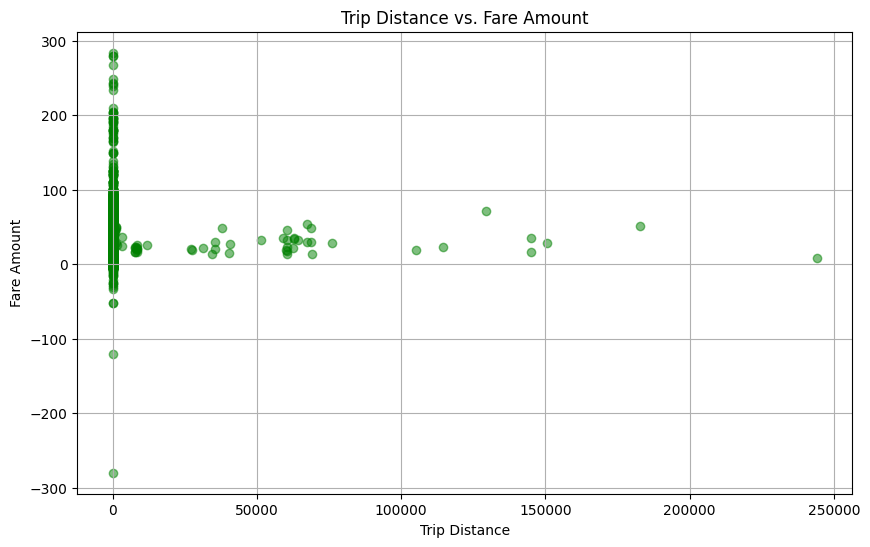

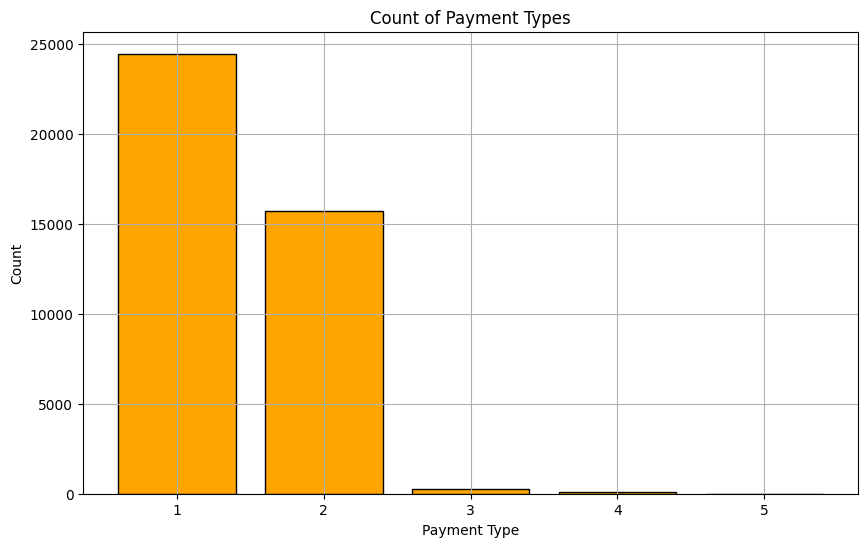

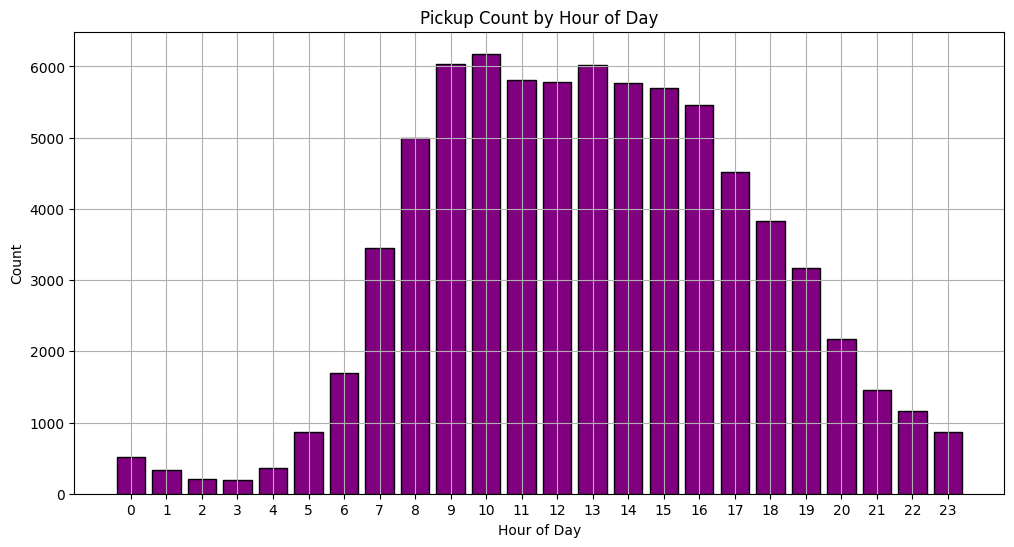

In [ ]:
# Histogram of trip distances
plt.figure(figsize=(10, 6))
plt.hist(df['trip_distance'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of Trip Distances')
plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Boxplot of fare amounts
plt.figure(figsize=(10, 6))
plt.boxplot(df['fare_amount'])
plt.title('Boxplot of Fare Amounts')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

# Scatter plot of trip distance vs. fare amount
plt.figure(figsize=(10, 6))
plt.scatter(df['trip_distance'], df['fare_amount'], alpha=0.5, color='green')
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

# Time series plot for pickups (if datetime column is available)
if 'lpep_pickup_datetime' in df.columns:
    df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
    pickup_counts = df['pickup_hour'].value_counts().sort_index()
    plt.figure(figsize=(12, 6))
    plt.bar(pickup_counts.index, pickup_counts.values, color='purple', edgecolor='black')
    plt.title('Pickup Count by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Count')
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()


I think we can drop rides over 100 miles. Some of them are absurdly large.

In [6]:
df["trip_distance"].info()

<class 'pandas.Series'>
RangeIndex: 76518 entries, 0 to 76517
Series name: trip_distance
Non-Null Count  Dtype  
--------------  -----  
76518 non-null  float64
dtypes: float64(1)
memory usage: 597.9 KB


In [7]:
df = df[(df["trip_distance"] <= 100) & (df["trip_distance"] > 0)].copy()

In [8]:
df["trip_distance"].info()

<class 'pandas.Series'>
Index: 73902 entries, 0 to 76517
Series name: trip_distance
Non-Null Count  Dtype  
--------------  -----  
73902 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


We should also drop negative fare amounts.

In [9]:
df["fare_amount"].info()

<class 'pandas.Series'>
Index: 73902 entries, 0 to 76517
Series name: fare_amount
Non-Null Count  Dtype  
--------------  -----  
73902 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


In [10]:
df = df[df["fare_amount"] > 0].copy()

In [11]:
df["fare_amount"].info()

<class 'pandas.Series'>
Index: 73775 entries, 0 to 76517
Series name: fare_amount
Non-Null Count  Dtype  
--------------  -----  
73775 non-null  float64
dtypes: float64(1)
memory usage: 1.1 MB


We can also drop the following columns as they dont seem useful.

In [12]:
df.drop([
    "VendorID", "store_and_fwd_flag", "payment_type", "trip_type", 
    "extra", "mta_tax", "tolls_amount", "improvement_surcharge",
    "congestion_surcharge", "ehail_fee", "passenger_count", "RatecodeID"
], axis=1, inplace=True)

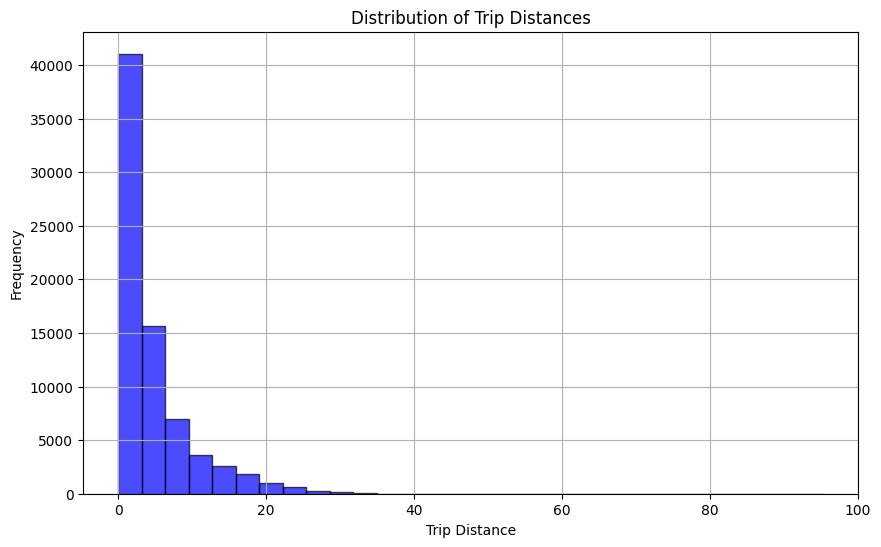

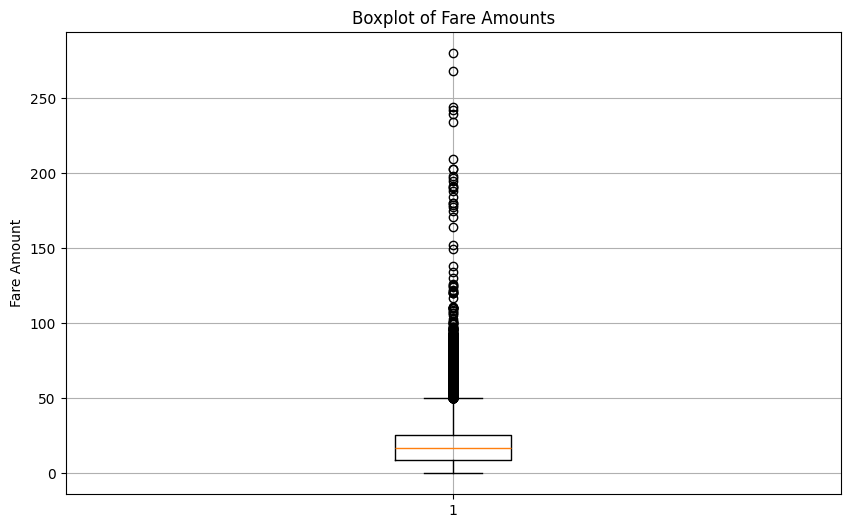

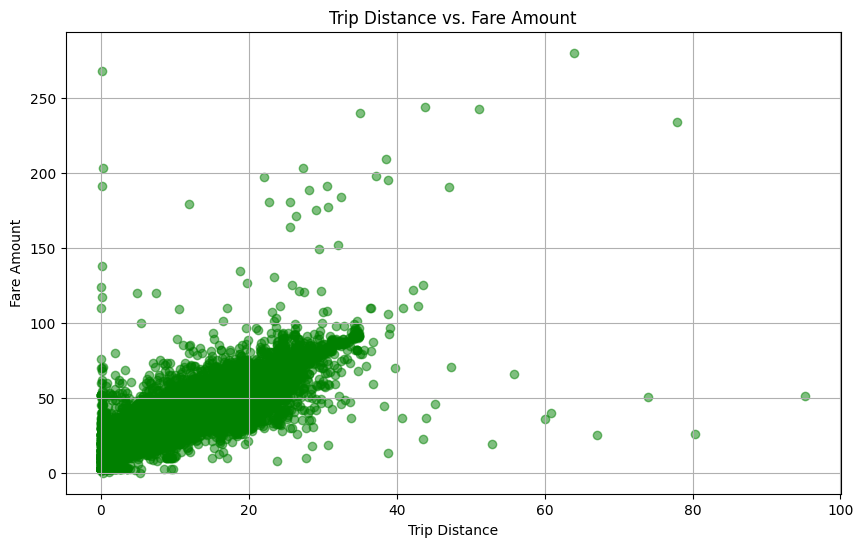

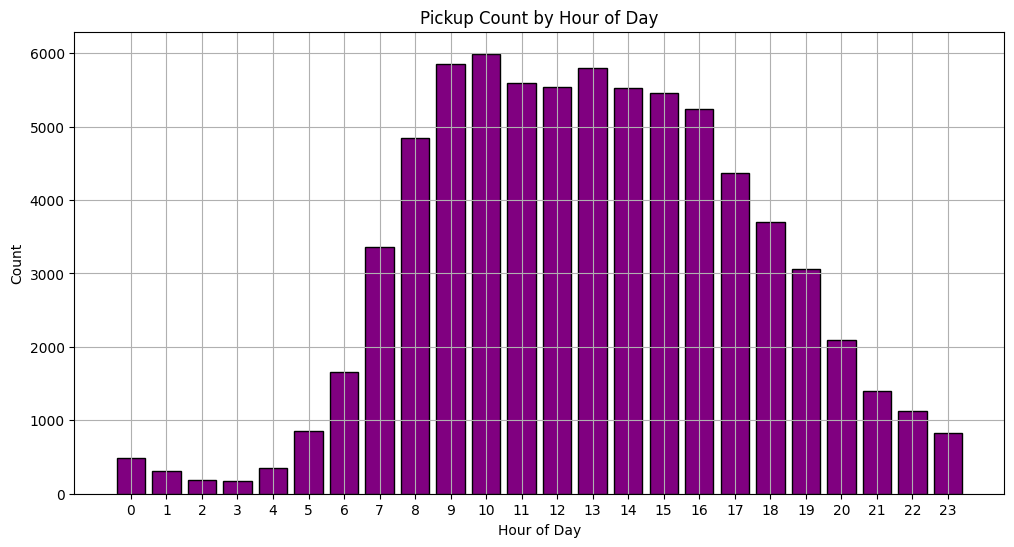

In [13]:
# Histogram of trip distances
plt.figure(figsize=(10, 6))
plt.hist(df['trip_distance'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of Trip Distances')
plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Boxplot of fare amounts
plt.figure(figsize=(10, 6))
plt.boxplot(df['fare_amount'])
plt.title('Boxplot of Fare Amounts')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

# Scatter plot of trip distance vs. fare amount
plt.figure(figsize=(10, 6))
plt.scatter(df['trip_distance'], df['fare_amount'], alpha=0.5, color='green')
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

# Bar plot for payment types (if available)
if 'payment_type' in df.columns:
    payment_counts = df['payment_type'].value_counts()
    plt.figure(figsize=(10, 6))
    plt.bar(payment_counts.index, payment_counts.values, color='orange', edgecolor='black')
    plt.title('Count of Payment Types')
    plt.xlabel('Payment Type')
    plt.ylabel('Count')
    plt.xticks(payment_counts.index)
    plt.grid(True)
    plt.show()

# Time series plot for pickups (if datetime column is available)
if 'lpep_pickup_datetime' in df.columns:
    df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
    pickup_counts = df['pickup_hour'].value_counts().sort_index()
    plt.figure(figsize=(12, 6))
    plt.bar(pickup_counts.index, pickup_counts.values, color='purple', edgecolor='black')
    plt.title('Pickup Count by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Count')
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()


There still some big outliers in fare amount and trip distance. I think for a better model I will drop these.

In [14]:
df = df[(df["trip_distance"] <= 20)].copy()


In [15]:
df

,lpep_pickup_datetime,lpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,pickup_hour
0,2021-01-01 00:15:56,2021-01-01 00:19:52,43,151,1.01,5.50,0.00,6.80,0
1,2021-01-01 00:25:59,2021-01-01 00:34:44,166,239,2.53,10.00,2.81,16.86,0
2,2021-01-01 00:45:57,2021-01-01 00:51:55,41,42,1.12,6.00,1.00,8.30,0
3,2020-12-31 23:57:51,2021-01-01 00:04:56,168,75,1.99,8.00,0.00,9.30,23
7,2021-01-01 00:26:31,2021-01-01 00:28:50,75,75,0.45,3.50,0.96,5.76,0
...,...,...,...,...,...,...,...,...,...
76513,2021-01-31 21:38:00,2021-01-31 22:16:00,81,90,17.63,56.23,0.00,65.40,21
76514,2021-01-31 22:43:00,2021-01-31 23:21:00,35,213,18.36,46.66,12.20,65.28,22
76515,2021-01-31 22:16:00,2021-01-31 22:27:00,74,69,2.50,18.95,0.00,22.00,22
76516,2021-01-31 23:10:00,2021-01-31 23:37:00,168,215,14.48,48.87,0.00,58.04,23


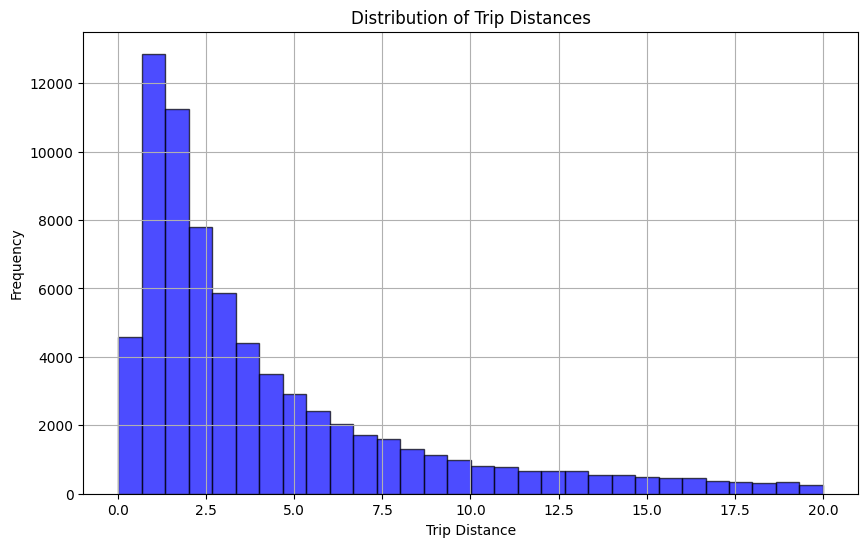

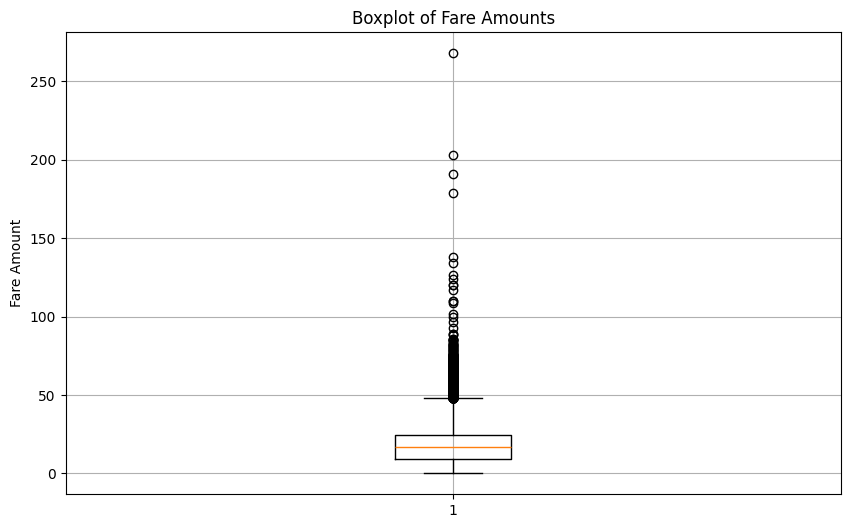

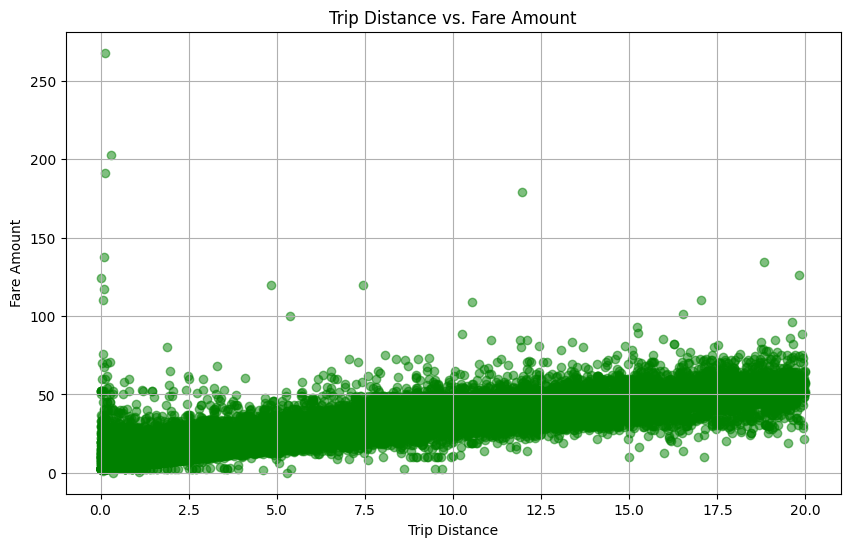

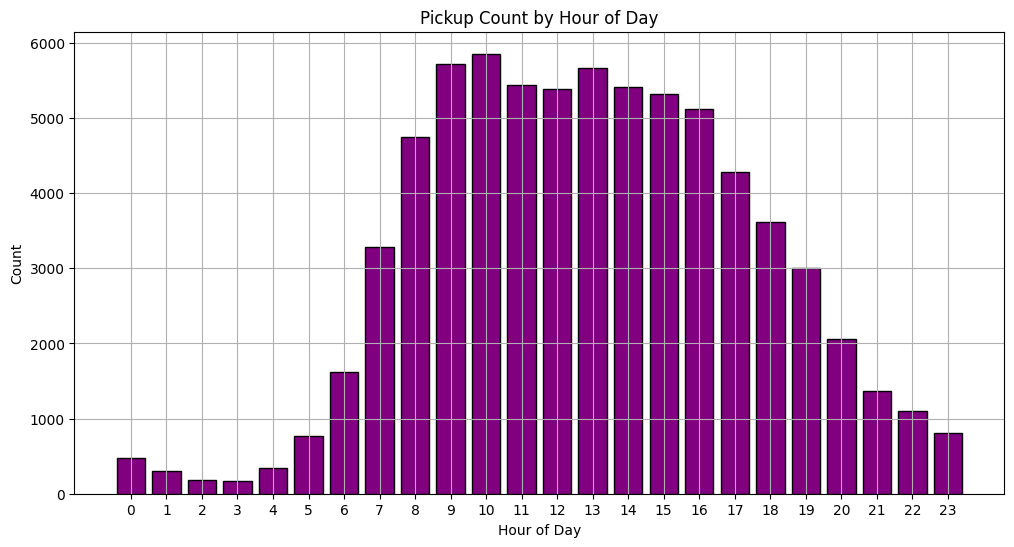

In [16]:
# Histogram of trip distances
plt.figure(figsize=(10, 6))
plt.hist(df['trip_distance'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of Trip Distances')
plt.xlabel('Trip Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Boxplot of fare amounts
plt.figure(figsize=(10, 6))
plt.boxplot(df['fare_amount'])
plt.title('Boxplot of Fare Amounts')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

# Scatter plot of trip distance vs. fare amount
plt.figure(figsize=(10, 6))
plt.scatter(df['trip_distance'], df['fare_amount'], alpha=0.5, color='green')
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

# Bar plot for payment types (if available)
if 'payment_type' in df.columns:
    payment_counts = df['payment_type'].value_counts()
    plt.figure(figsize=(10, 6))
    plt.bar(payment_counts.index, payment_counts.values, color='orange', edgecolor='black')
    plt.title('Count of Payment Types')
    plt.xlabel('Payment Type')
    plt.ylabel('Count')
    plt.xticks(payment_counts.index)
    plt.grid(True)
    plt.show()

# Time series plot for pickups (if datetime column is available)
if 'lpep_pickup_datetime' in df.columns:
    df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
    pickup_counts = df['pickup_hour'].value_counts().sort_index()
    plt.figure(figsize=(12, 6))
    plt.bar(pickup_counts.index, pickup_counts.values, color='purple', edgecolor='black')
    plt.title('Pickup Count by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Count')
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()


We started with 76518 rows and now after cleanup we have 72064 left.

In [17]:
df.to_parquet("clean_tripdata.parquet", index=False)